Customer Churn Data Preparation & EDA
Name: Sneha Bharmal
Task 3 - Data Science Project

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [8]:
df = df.dropna()

In [9]:
df = df.drop(columns=["customerID"], errors='ignore')

In [10]:
def tenure_group(x):
    if x <= 12:
        return "0-12"
    elif x <= 24:
        return "13-24"
    elif x <= 48:
        return "25-48"
    else:
        return "48+"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [11]:
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]

In [12]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [13]:
df = pd.get_dummies(df, drop_first=True)

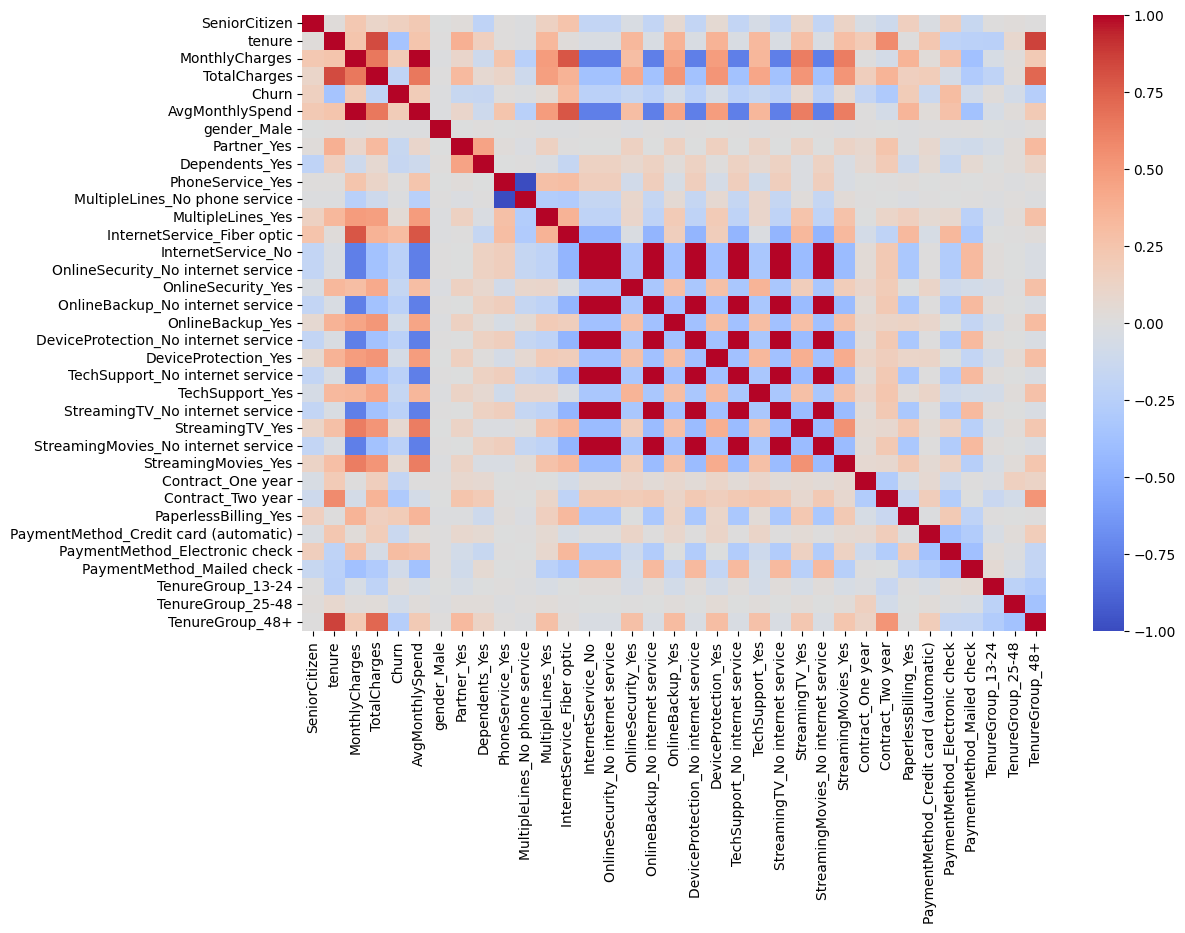

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

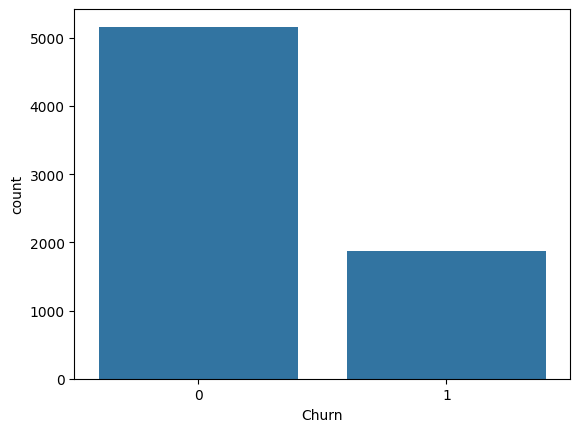

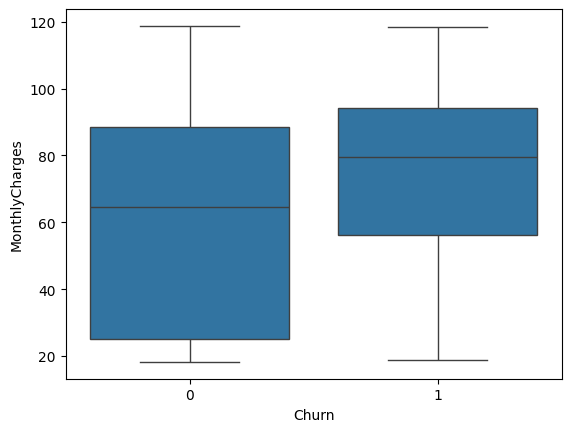

In [15]:
sns.countplot(x="Churn", data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [16]:
df.to_csv("cleaned_churn.csv", index=False)

1. Customers with higher monthly charges churn more.
2. Customers with longer tenure stay longer.
3. Month-to-month contracts have higher churn.
4. Fiber optic users churn more.
5. Senior citizens churn slightly more.